CT shape: (1024, 1024, 114)


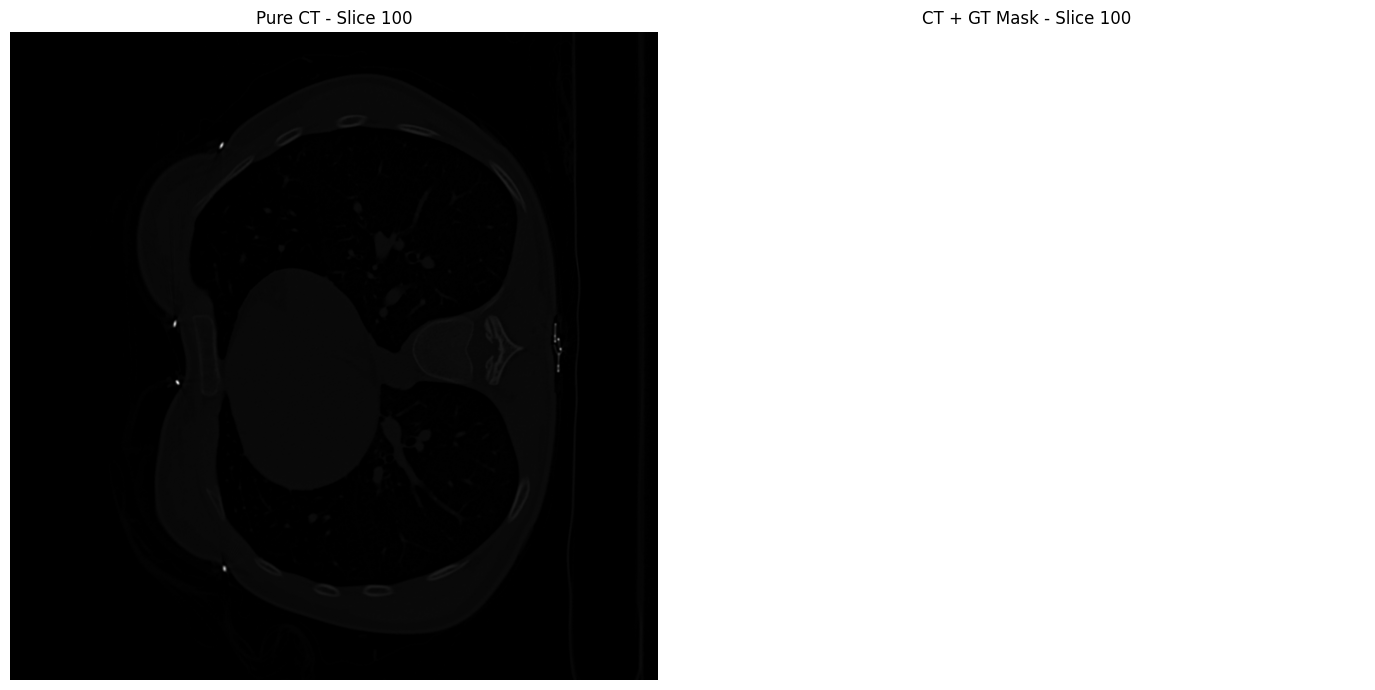

In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_13441_a_2.nii.gz"


ct = nib.load(volume_path).get_fdata()


print("CT shape:", ct.shape)


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, 50],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice 100")
axes[0].axis("off")


axes[1].set_title(f"CT + GT Mask - Slice 100")
axes[1].axis("off")


plt.tight_layout()
plt.show()

CT shape: (512, 512, 513)
GT mask shape: (2, 512, 512, 513)
GT labels: [0. 1. 2. 3.]
Using GT mask shape: (512, 512, 513)
Displaying slice: 289

Voxel counts
CT total voxels        : 134479872
Mask total voxels      : 134479872
Mask positive voxels   : 774269
Mask background voxels : 133705603
Mask percentage of CT  : 0.575751%


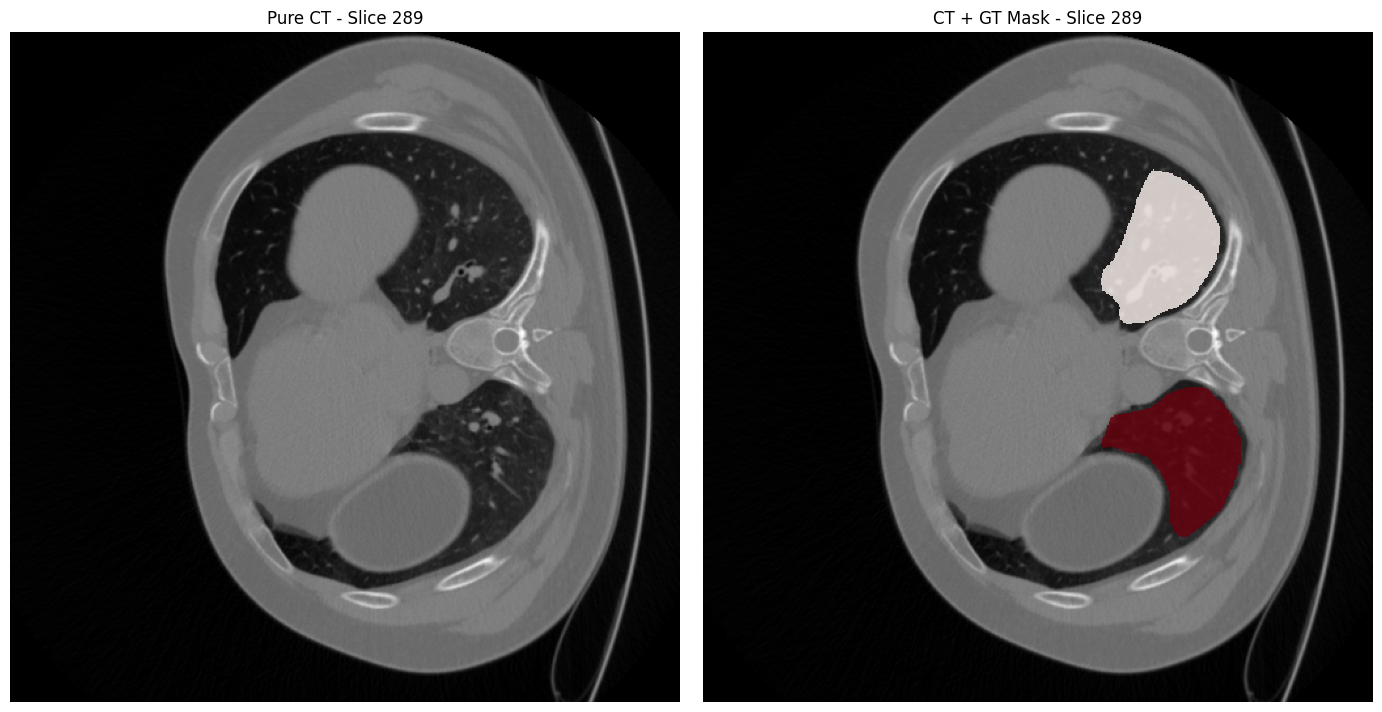

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_2250_a_2.nii.gz"

mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_2250_a_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()


print("CT shape:", ct.shape)
print("GT mask shape:", gt_mask.shape)
print("GT labels:", np.unique(gt_mask)[:20])


# -----------------------------
# Handle mask dimensions
# -----------------------------

if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most nodule
# -----------------------------

slice_idx = np.argmax(
    (gt_mask > 0).sum(axis=(0, 1))
)

print("Displaying slice:", slice_idx)

# -----------------------------
# Voxel counts
# -----------------------------

ct_voxels = ct.size
mask_voxels = gt_mask.size

positive_mask_voxels = np.count_nonzero(gt_mask > 0)
zero_mask_voxels = mask_voxels - positive_mask_voxels

mask_percentage_of_volume = (positive_mask_voxels / ct_voxels) * 100

print("\nVoxel counts")
print("CT total voxels        :", ct_voxels)
print("Mask total voxels      :", mask_voxels)
print("Mask positive voxels   :", positive_mask_voxels)
print("Mask background voxels :", zero_mask_voxels)
print(f"Mask percentage of CT  : {mask_percentage_of_volume:.6f}%")


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice {slice_idx}")
axes[0].axis("off")


# CT + GT mask overlay
axes[1].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

seg = gt_mask[:, :, slice_idx]

axes[1].imshow(
    np.ma.masked_where(
        seg <= 0,
        seg
    ),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[1].set_title(f"CT + GT Mask - Slice {slice_idx}")
axes[1].axis("off")


plt.tight_layout()
plt.show()

CT: (512, 512, 512)
Mask: (6, 512, 512, 512)
Binary mask: (512, 512, 512)
Foreground voxels: 52340

Bounding box
(np.int64(160), np.int64(353), np.int64(188), np.int64(235), np.int64(372), np.int64(405))

Collected patches: 3725

Patch index: 1536
Origin: (267, 201, 379)
Lesion fraction: 0.620361328125
Patch L2 norm: 49362.80349615488


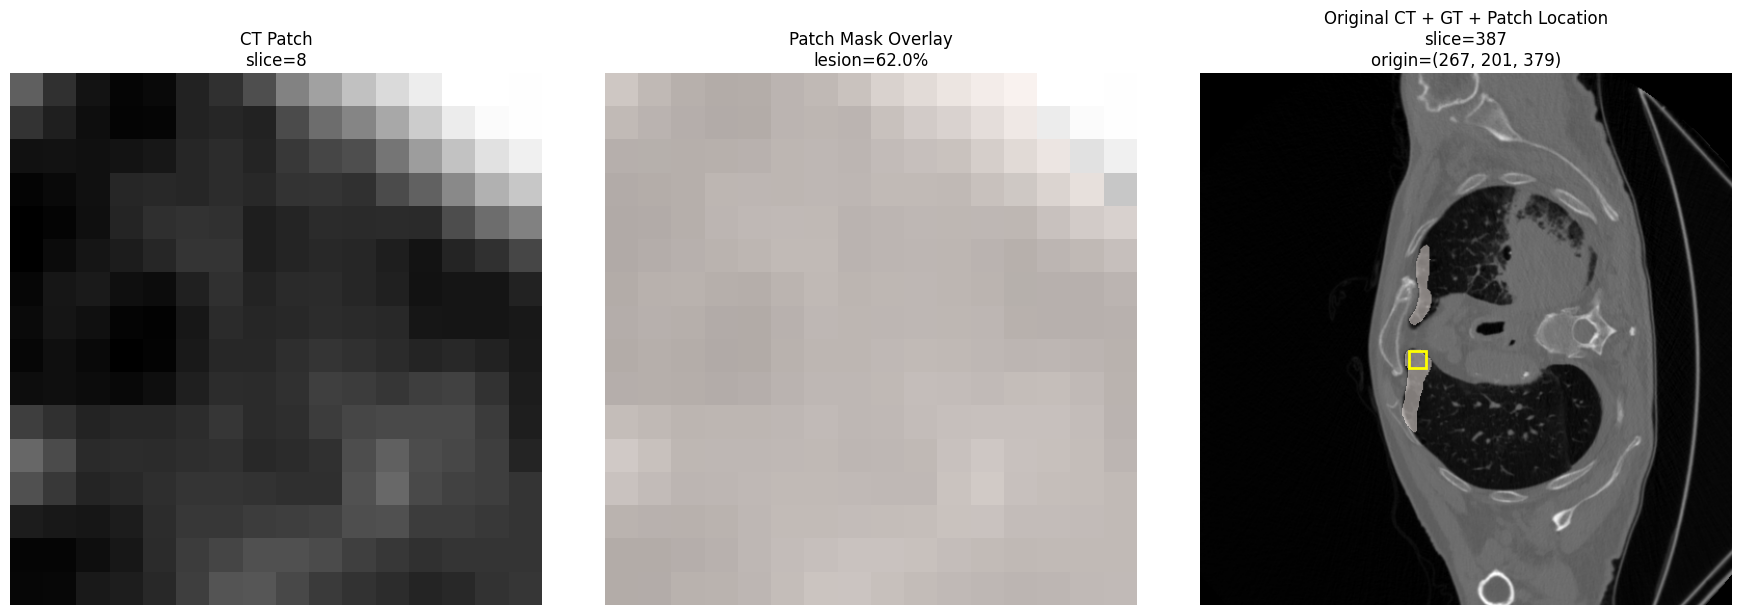


Patch index: 1020
Origin: (223, 209, 373)
Lesion fraction: 0.84716796875
Patch L2 norm: 51670.47874754017


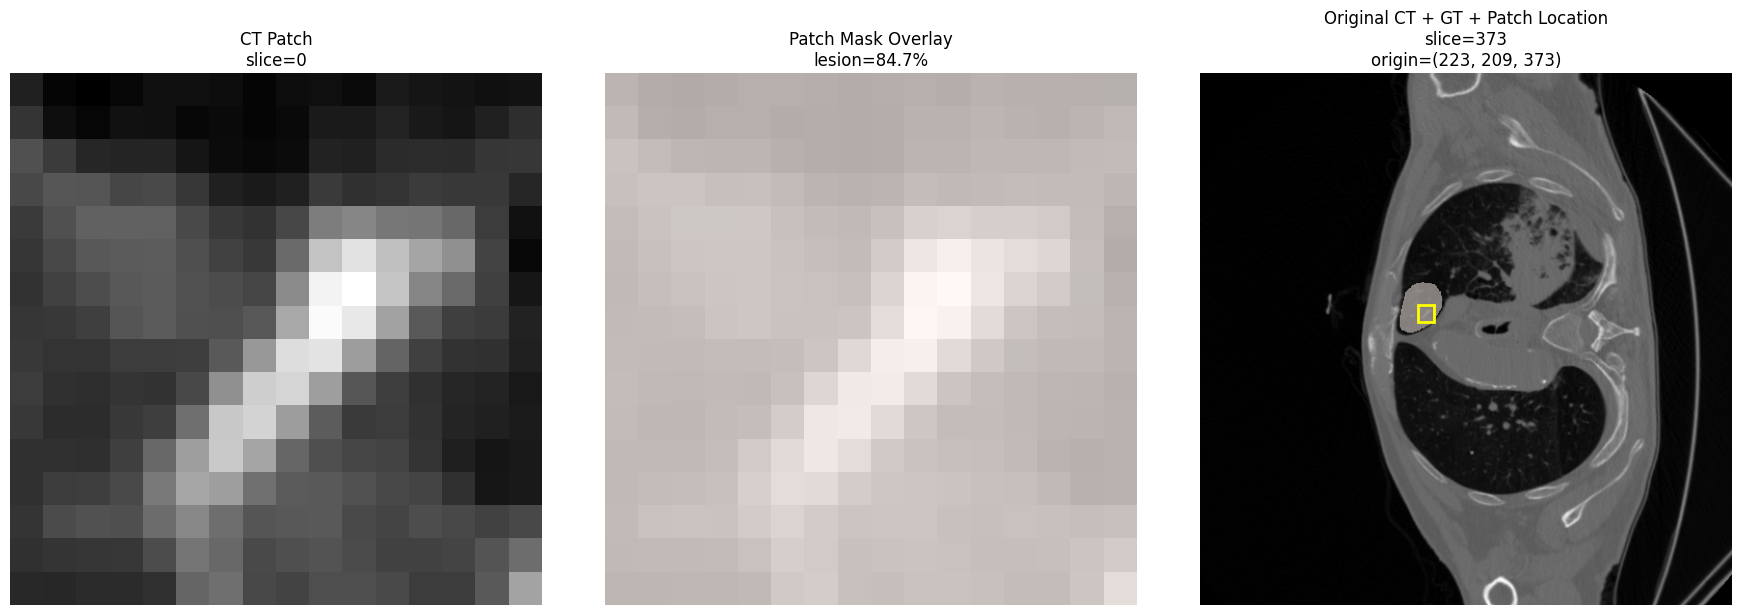


Patch index: 9
Origin: (189, 207, 375)
Lesion fraction: 0.50927734375
Patch L2 norm: 53950.30781191151


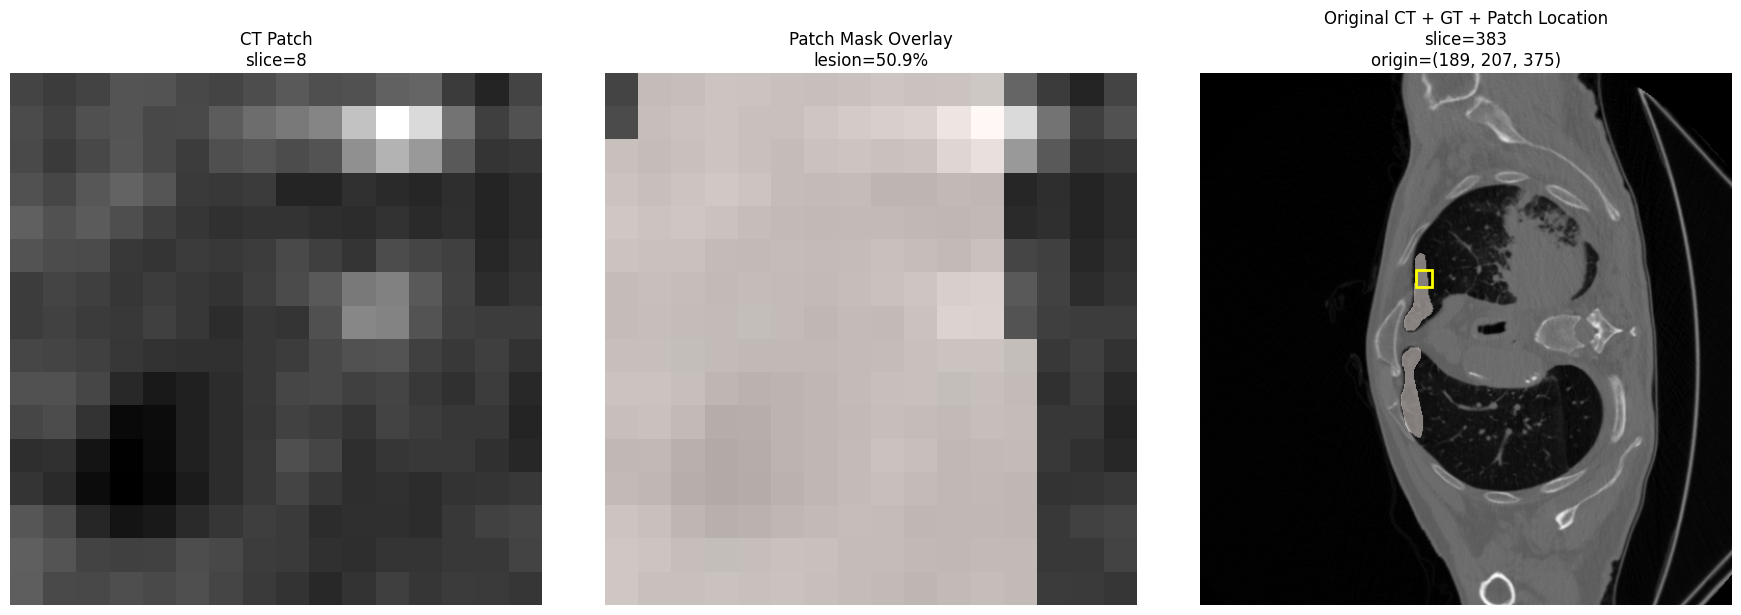


Patch index: 2105
Origin: (301, 193, 381)
Lesion fraction: 0.584716796875
Patch L2 norm: 44941.713296224036


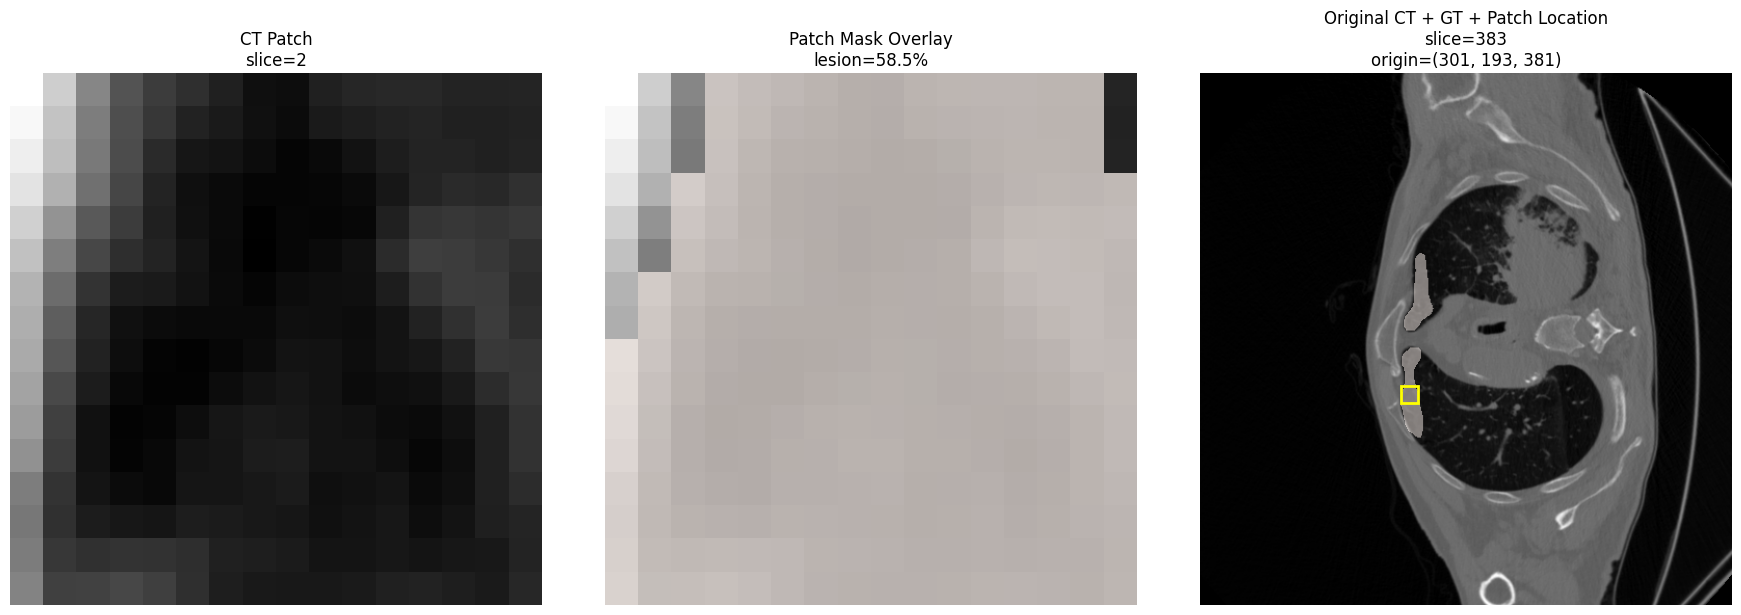


Patch index: 3467
Origin: (327, 207, 389)
Lesion fraction: 0.761962890625
Patch L2 norm: 54874.58938342956


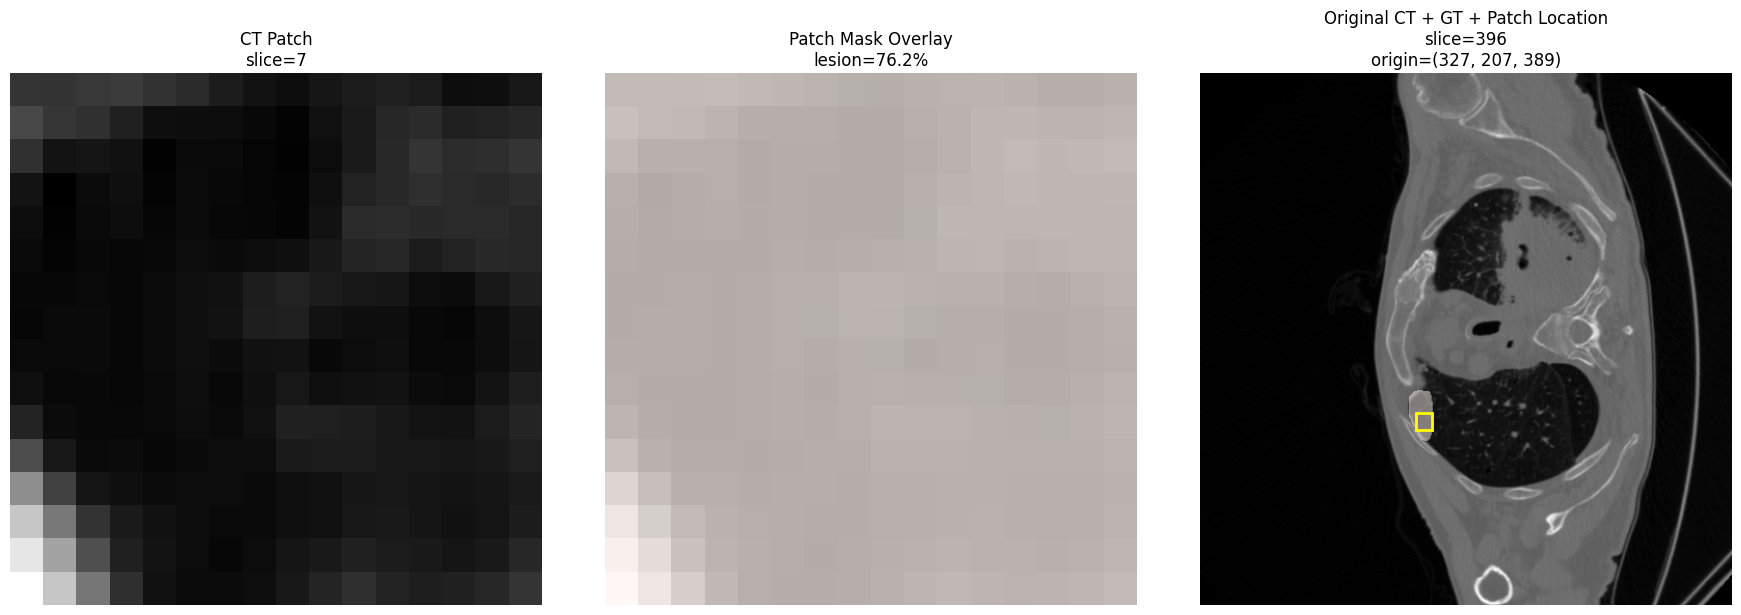

In [24]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# =============================
# Parameters (same as pipeline)
# =============================

PATCH_SIZE = 16
ABNORMAL_PATCH_STRIDE = 2
LESION_FRACTION_THRESHOLD = 0.5


# =============================
# Load CT and mask
# =============================

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1448_c_2.nii.gz"
mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_1448_c_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
mask = nib.load(mask_path).get_fdata()


print("CT:", ct.shape)
print("Mask:", mask.shape)


# Handle 4D masks
if mask.ndim == 4:
    finding = 0
    mask = mask[finding]


mask = (mask > 0).astype(np.uint8)

print("Binary mask:", mask.shape)
print("Foreground voxels:", mask.sum())



# =============================
# Helper functions (same logic)
# =============================

def has_sufficient_lesion(mask_patch):
    return (mask_patch > 0).mean() >= LESION_FRACTION_THRESHOLD



def foreground_bbox(binary_mask):

    coords = np.argwhere(binary_mask > 0)

    x_min, y_min, z_min = coords.min(axis=0)
    x_max, y_max, z_max = coords.max(axis=0)

    return (
        x_min, x_max,
        y_min, y_max,
        z_min, z_max
    )



def bbox_origins(bbox, volume_shape, stride):

    p = PATCH_SIZE

    H, W, D = volume_shape

    x_min, x_max, y_min, y_max, z_min, z_max = bbox


    x_start = max(0, x_min - p + 1)
    x_stop  = min(H-p, x_max)

    y_start = max(0, y_min - p + 1)
    y_stop  = min(W-p, y_max)

    z_start = max(0, z_min - p + 1)
    z_stop  = min(D-p, z_max)


    for x0 in range(x_start, x_stop+1, stride):
        for y0 in range(y_start, y_stop+1, stride):
            for z0 in range(z_start, z_stop+1, stride):
                yield x0,y0,z0



def extract_patch(volume, x,y,z):

    return volume[
        x:x+PATCH_SIZE,
        y:y+PATCH_SIZE,
        z:z+PATCH_SIZE
    ]



# =============================
# Generate patches
# =============================

bbox = foreground_bbox(mask)

print("\nBounding box")
print(bbox)


patches = []


for x,y,z in bbox_origins(
    bbox,
    ct.shape,
    ABNORMAL_PATCH_STRIDE
):

    ct_patch = extract_patch(ct,x,y,z)
    mask_patch = extract_patch(mask,x,y,z)


    if has_sufficient_lesion(mask_patch):

        patches.append(
            {
                "origin":(x,y,z),
                "ct":ct_patch,
                "mask":mask_patch,
                "lesion_fraction":(mask_patch>0).mean()
            }
        )


print("\nCollected patches:",len(patches))



# =============================
# Visualize selected patches
# =============================

def show_patch(patch):

    ct_patch = patch["ct"]
    mask_patch = patch["mask"]

    x0, y0, z0 = patch["origin"]


    # choose patch slice with highest lesion pixels
    slice_idx = np.argmax(
        (mask_patch > 0).sum(axis=(0,1))
    )

    # Corresponding slice in original CT
    original_z = z0 + slice_idx


    fig, ax = plt.subplots(
        1, 3,
        figsize=(18, 6)
    )


    # ---------------------------------
    # 1. Patch CT
    # ---------------------------------

    ax[0].imshow(
        ct_patch[:, :, slice_idx],
        cmap="gray"
    )

    ax[0].set_title(
        f"CT Patch\nslice={slice_idx}"
    )

    ax[0].axis("off")



    # ---------------------------------
    # 2. Patch + mask overlay
    # ---------------------------------

    ax[1].imshow(
        ct_patch[:, :, slice_idx],
        cmap="gray"
    )

    ax[1].imshow(
        np.ma.masked_where(
            mask_patch[:, :, slice_idx] == 0,
            mask_patch[:, :, slice_idx]
        ),
        cmap="Reds",
        alpha=0.7
    )

    ax[1].set_title(
        f"Patch Mask Overlay\n"
        f"lesion={patch['lesion_fraction']*100:.1f}%"
    )

    ax[1].axis("off")



    # ---------------------------------
    # 3. Original CT + GT + patch box
    # ---------------------------------

    ax[2].imshow(
        ct[:, :, original_z],
        cmap="gray"
    )


    # Full GT mask overlay
    ax[2].imshow(
        np.ma.masked_where(
            mask[:, :, original_z] == 0,
            mask[:, :, original_z]
        ),
        cmap="Reds",
        alpha=0.5
    )


    # Draw patch bounding box
    rect = plt.Rectangle(
        (y0, x0),
        PATCH_SIZE,
        PATCH_SIZE,
        fill=False,
        edgecolor="yellow",
        linewidth=2
    )

    ax[2].add_patch(rect)


    ax[2].set_title(
        f"Original CT + GT + Patch Location\n"
        f"slice={original_z}\n"
        f"origin={patch['origin']}"
    )

    ax[2].axis("off")


    plt.tight_layout()
    plt.show()



import numpy as np

# Number of random patches to display
num_show = 5

# Select random patch indices
random_indices = np.random.choice(
    len(patches),
    size=min(num_show, len(patches)),
    replace=False
)


for i in random_indices:

    p = patches[i]

    patch_norm = np.linalg.norm(p["ct"])


    print(
        f"\nPatch index: {i}"
    )

    print(
        "Origin:",
        p["origin"]
    )

    print(
        "Lesion fraction:",
        p["lesion_fraction"]
    )

    print(
        "Patch L2 norm:",
        patch_norm
    )

    show_patch(p)

In [14]:
import numpy as np

patch_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz"

data = np.load(
    patch_path,
    allow_pickle=True
)

print("Keys:", data.files)

for key in data.files:
    print(key, data[key].shape, data[key].dtype)

Keys: ['X', 'H', 'scan_ids']
X (4096, 38694) float64
H (38694,) int64
scan_ids (38694,) object


In [27]:
scan_ids = data["scan_ids"]
X = data["X"]
norms = np.linalg.norm(X, axis=0)

zero_scan_indices = np.where(
    scan_ids == "train_1448_c_2.nii.gz"
)[0]

print("\nIndices of patches from scan 'train_1448_c_2.nii.gz':", zero_scan_indices)

for idx in zero_scan_indices[:20]:

    print(
        idx,
        norms[idx],
        X[:,idx].min(),
        X[:,idx].max()
    )


Indices of patches from scan 'train_1448_c_2.nii.gz': []


In [15]:
X = data["X"]

print("Patch matrix shape:", X.shape)

# Each column = one patch
patch_norms = np.linalg.norm(X, axis=0)

zero_mask = patch_norms < 1e-10


print("\n===== Patch Norm Statistics =====")
print("Total patches:", X.shape[1])
print("Zero norm patches:", zero_mask.sum())

print(
    f"Percentage zero norm patches: "
    f"{zero_mask.sum()/X.shape[1]*100:.6f}%"
)


print("\nNorm statistics")
print("Min norm:", patch_norms.min())
print("Max norm:", patch_norms.max())
print("Mean norm:", patch_norms.mean())
print("Median norm:", np.median(patch_norms))

Patch matrix shape: (4096, 38694)

===== Patch Norm Statistics =====
Total patches: 38694
Zero norm patches: 1268
Percentage zero norm patches: 3.276994%

Norm statistics
Min norm: 0.0
Max norm: 32.890171215229635
Mean norm: 12.589202517113288
Median norm: 10.288001359164205


In [16]:
import numpy as np

patch_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train.npz"

data = np.load(
    patch_path,
    allow_pickle=True
)

X = data["X"]
scan_ids = data["scan_ids"]

# Compute norms
patch_norms = np.linalg.norm(X, axis=0)

# Find zero norm patches
zero_mask = patch_norms < 1e-10

# Get scan IDs corresponding to zero norm patches
zero_norm_scan_ids = scan_ids[zero_mask]


print("Number of zero norm patches:", len(zero_norm_scan_ids))

print("\nFirst 20 zero norm patch scan IDs:")
print(zero_norm_scan_ids[:20])

Number of zero norm patches: 1268

First 20 zero norm patch scan IDs:
['train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2'
 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2'
 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2'
 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2'
 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2' 'train_1448_c_2']


In [20]:
unique_zero_scan_ids, counts = np.unique(
    zero_norm_scan_ids,
    return_counts=True
)

print("Number of scans containing zero-norm patches:",
      len(unique_zero_scan_ids))

for scan_id, count in zip(unique_zero_scan_ids, counts):
    print(scan_id, "->", count, "zero-norm patches")

Number of scans containing zero-norm patches: 8
train_122_b_1 -> 841 zero-norm patches
train_1448_c_2 -> 249 zero-norm patches
train_5668_a_2 -> 5 zero-norm patches
train_6970_a_2 -> 26 zero-norm patches
train_6970_b_2 -> 108 zero-norm patches
train_7244_a_1 -> 25 zero-norm patches
train_7641_b_2 -> 11 zero-norm patches
train_7858_a_2 -> 3 zero-norm patches


In [21]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


# -----------------------------
# Helper: keep largest components
# -----------------------------
def keep_largest_components(binary_mask, n=2):
    """
    Keep the n largest connected components from a 3D binary mask.
    """
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0  # ignore background

    largest_labels = np.argsort(component_sizes)[-n:]

    return np.isin(labeled, largest_labels)

# -----------------------------
# Handle GT mask dimensions
# -----------------------------
if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most GT mask pixels
# -----------------------------
slice_idx = int(np.argmax((gt_mask > 0).sum(axis=(0, 1))))

print("Displaying slice:", slice_idx)
print("GT pixels on slice:", int((gt_mask[:, :, slice_idx] > 0).sum()))


# ============================================================
# Lung preprocessing pipeline
# ============================================================

# -----------------------------
# 1. HU threshold
# -----------------------------
lung_candidate = (ct >= -900) & (ct <= -200)


# -----------------------------
# 2. Remove border air slice-by-slice
# -----------------------------
mask_clear = np.zeros_like(lung_candidate, dtype=bool)

for k in range(lung_candidate.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])


# -----------------------------
# 3. Keep two largest 3D components
# -----------------------------
lungs_only = keep_largest_components(mask_clear, n=2)


# -----------------------------
# 4. Morphological closing
# -----------------------------
structure = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(
    lungs_only,
    structure=structure,
    iterations=2
)


# -----------------------------
# 5. Hole filling
# -----------------------------
mask_filled = ndimage.binary_fill_holes(mask_closed)


# -----------------------------
# 6. Final cleanup
# -----------------------------
lungs_final = ndimage.binary_closing(
    mask_filled,
    structure=structure,
    iterations=2
)

lungs_final = ndimage.binary_fill_holes(lungs_final)


# -----------------------------
# Apply final lung mask to CT
# -----------------------------
# Outside-lung voxels are set to a very dark HU value.
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# ============================================================
# Visualization
# ============================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
lung_candidate_slice = lung_candidate[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

# 0. Original CT
axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title(f"Original CT - Slice {slice_idx}")
axes[0].axis("off")

# 1. HU threshold mask
axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. HU Threshold [-900, -200]")
axes[1].axis("off")

# 2. Clear border
axes[2].imshow(mask_clear_slice, cmap="gray")
axes[2].set_title("2. Remove Border Air")
axes[2].axis("off")

# 3. Keep largest components
axes[3].imshow(lungs_only_slice, cmap="gray")
axes[3].set_title("3. Keep Two Largest Components")
axes[3].axis("off")

# 4. Closing
axes[4].imshow(mask_closed_slice, cmap="gray")
axes[4].set_title("4. Morphological Closing")
axes[4].axis("off")

# 5. Hole filling
axes[5].imshow(mask_filled_slice, cmap="gray")
axes[5].set_title("5. Hole Filling")
axes[5].axis("off")

# 6. Final lung mask
axes[6].imshow(lungs_final_slice, cmap="gray")
axes[6].set_title("6. Final Lung Mask")
axes[6].axis("off")

# 7. CT after applying lung mask
axes[7].imshow(ct_lung_only_slice, cmap="gray")
axes[7].set_title("7. CT After Applying Final Lung Mask")
axes[7].axis("off")

# 8. Final CT + GT overlay
axes[8].imshow(ct_lung_only_slice, cmap="gray")

axes[8].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[8].set_title("8. Final Lung-Masked CT + GT Overlay")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Optional: print voxel counts
# ============================================================
print("Voxel counts:")
print("HU threshold mask:", int(lung_candidate.sum()))
print("After clear_border:", int(mask_clear.sum()))
print("After largest components:", int(lungs_only.sum()))
print("After closing:", int(mask_closed.sum()))
print("After hole filling:", int(mask_filled.sum()))
print("Final lung mask:", int(lungs_final.sum()))
print("GT mask:", int((gt_mask > 0).sum()))

Using GT mask shape: (512, 512, 513)
Displaying slice: 289
GT pixels on slice: 13667


KeyboardInterrupt: 

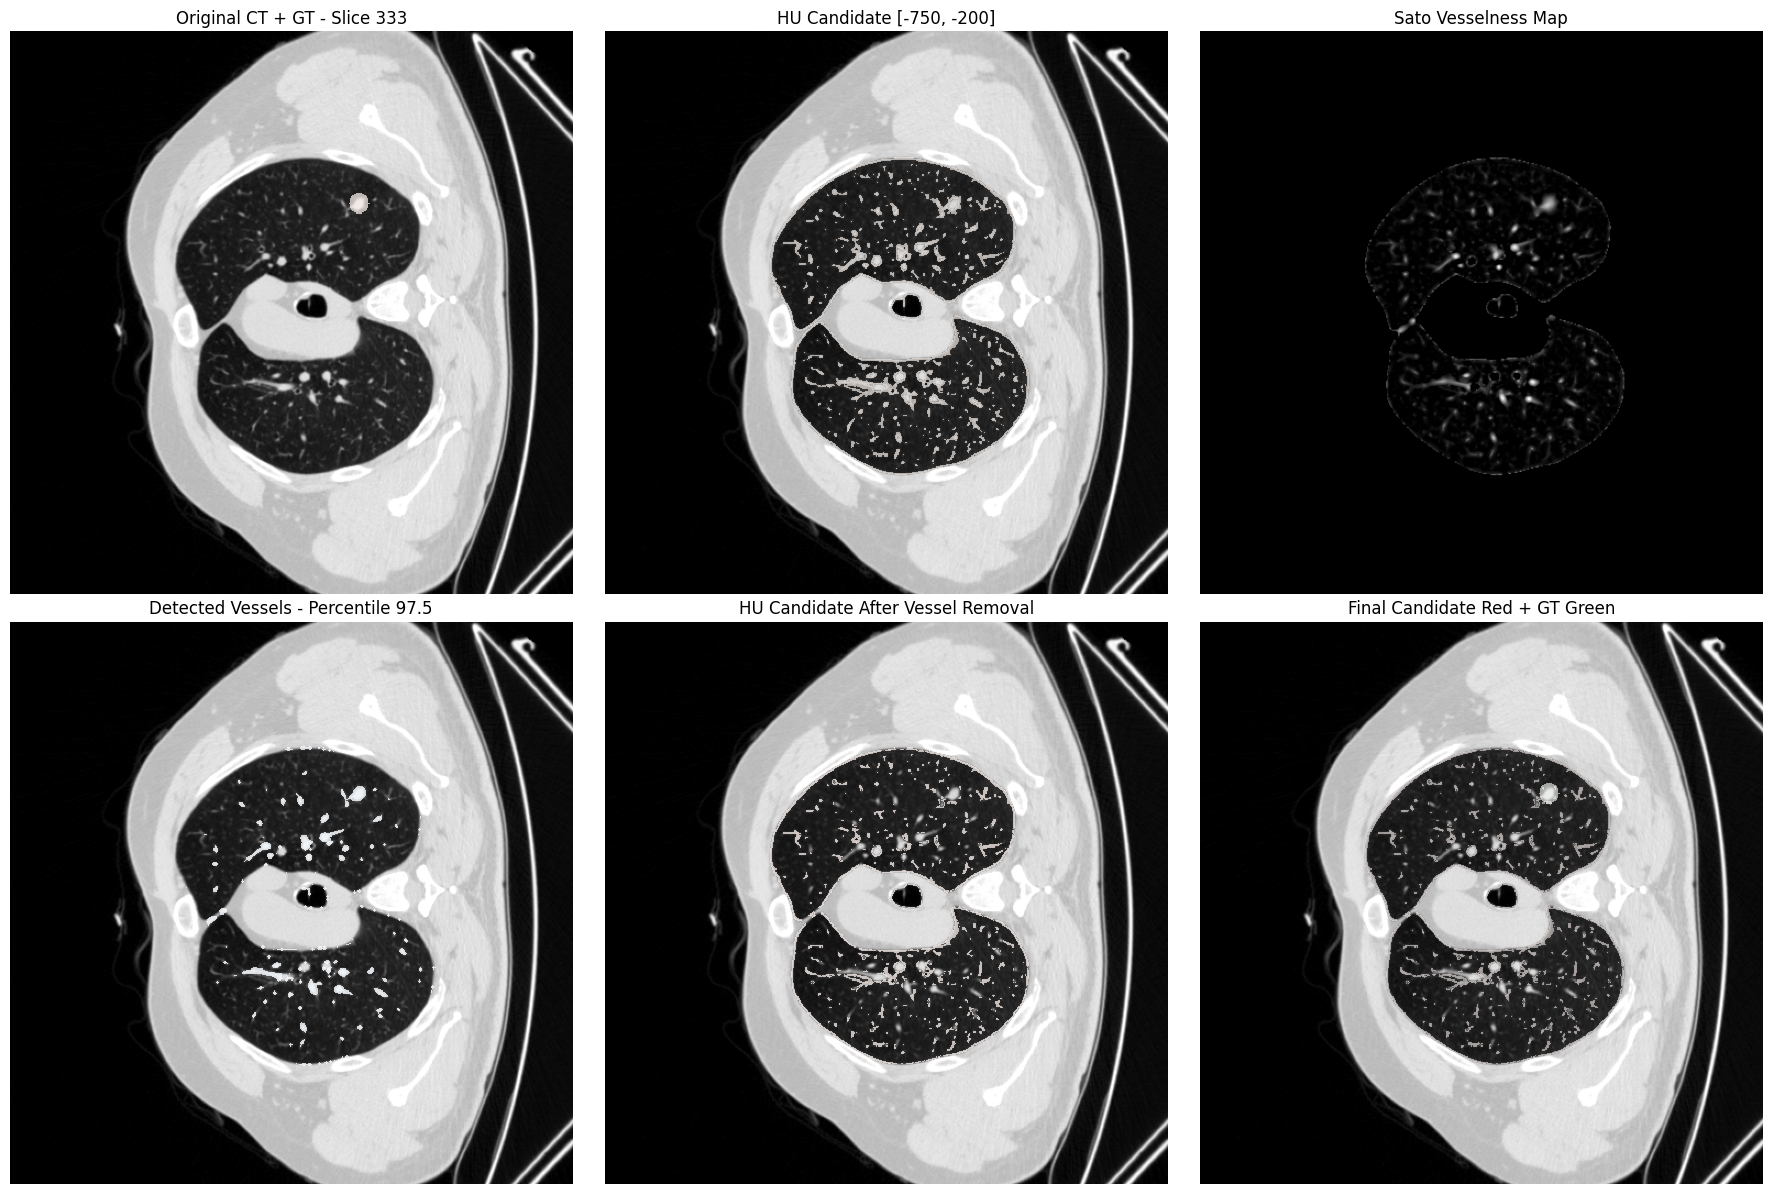

Voxel counts:
Lung mask: 12544165
HU candidate [-750, -200]: 2247241
Detected vessel voxels: 734810
After vessel removal: 1701771
After cleanup: 1604691
GT mask: 7253

Sato vesselness:
Min: 0.0
Mean: 0.013876486237938886
Max: 0.2522813204384149
Threshold: 0.08341051879606953


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


# -----------------------------
# Helper: keep largest components
# -----------------------------
def keep_largest_components(binary_mask, n=2):
    """
    Keep the n largest connected components from a 3D binary mask.
    """
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0  # ignore background

    largest_labels = np.argsort(component_sizes)[-n:]

    return np.isin(labeled, largest_labels)

# -----------------------------
# Handle GT mask dimensions
# -----------------------------
if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most GT mask pixels
# -----------------------------
slice_idx = int(np.argmax((gt_mask > 0).sum(axis=(0, 1))))

print("Displaying slice:", slice_idx)
print("GT pixels on slice:", int((gt_mask[:, :, slice_idx] > 0).sum()))


# ============================================================
# Lung preprocessing pipeline
# ============================================================

# -----------------------------
# 1. HU threshold
# -----------------------------
lung_candidate = (ct >= -900) & (ct <= -200)


# -----------------------------
# 2. Remove border air slice-by-slice
# -----------------------------
mask_clear = np.zeros_like(lung_candidate, dtype=bool)

for k in range(lung_candidate.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])


# -----------------------------
# 3. Keep two largest 3D components
# -----------------------------
lungs_only = keep_largest_components(mask_clear, n=2)


# -----------------------------
# 4. Morphological closing
# -----------------------------
structure = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(
    lungs_only,
    structure=structure,
    iterations=2
)


# -----------------------------
# 5. Hole filling
# -----------------------------
mask_filled = ndimage.binary_fill_holes(mask_closed)


# -----------------------------
# 6. Final cleanup
# -----------------------------
lungs_final = ndimage.binary_closing(
    mask_filled,
    structure=structure,
    iterations=2
)

lungs_final = ndimage.binary_fill_holes(lungs_final)


# -----------------------------
# Apply final lung mask to CT
# -----------------------------
# Outside-lung voxels are set to a very dark HU value.
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# ============================================================
# Visualization
# ============================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
lung_candidate_slice = lung_candidate[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

# 0. Original CT
axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title(f"Original CT - Slice {slice_idx}")
axes[0].axis("off")

# 1. HU threshold mask
axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. HU Threshold [-900, -200]")
axes[1].axis("off")

# 2. Clear border
axes[2].imshow(mask_clear_slice, cmap="gray")
axes[2].set_title("2. Remove Border Air")
axes[2].axis("off")

# 3. Keep largest components
axes[3].imshow(lungs_only_slice, cmap="gray")
axes[3].set_title("3. Keep Two Largest Components")
axes[3].axis("off")

# 4. Closing
axes[4].imshow(mask_closed_slice, cmap="gray")
axes[4].set_title("4. Morphological Closing")
axes[4].axis("off")

# 5. Hole filling
axes[5].imshow(mask_filled_slice, cmap="gray")
axes[5].set_title("5. Hole Filling")
axes[5].axis("off")

# 6. Final lung mask
axes[6].imshow(lungs_final_slice, cmap="gray")
axes[6].set_title("6. Final Lung Mask")
axes[6].axis("off")

# 7. CT after applying lung mask
axes[7].imshow(ct_lung_only_slice, cmap="gray")
axes[7].set_title("7. CT After Applying Final Lung Mask")
axes[7].axis("off")

# 8. Final CT + GT overlay
axes[8].imshow(ct_lung_only_slice, cmap="gray")

axes[8].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[8].set_title("8. Final Lung-Masked CT + GT Overlay")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Optional: print voxel counts
# ============================================================
print("Voxel counts:")
print("HU threshold mask:", int(lung_candidate.sum()))
print("After clear_border:", int(mask_clear.sum()))
print("After largest components:", int(lungs_only.sum()))
print("After closing:", int(mask_closed.sum()))
print("After hole filling:", int(mask_filled.sum()))
print("Final lung mask:", int(lungs_final.sum()))
print("GT mask:", int((gt_mask > 0).sum()))

Number of GT voxels: 7253

HU distribution inside GT mask
Min : -903.0
P1  : -864.0
P5  : -837.0
P25 : -765.0
P50 : -616.0
P75 : -232.0
P95 : 32.0
P99 : 55.0
Max : 78.0
Mean: -499.9619467806425
Median: -616.0
Std : 305.4109620077608


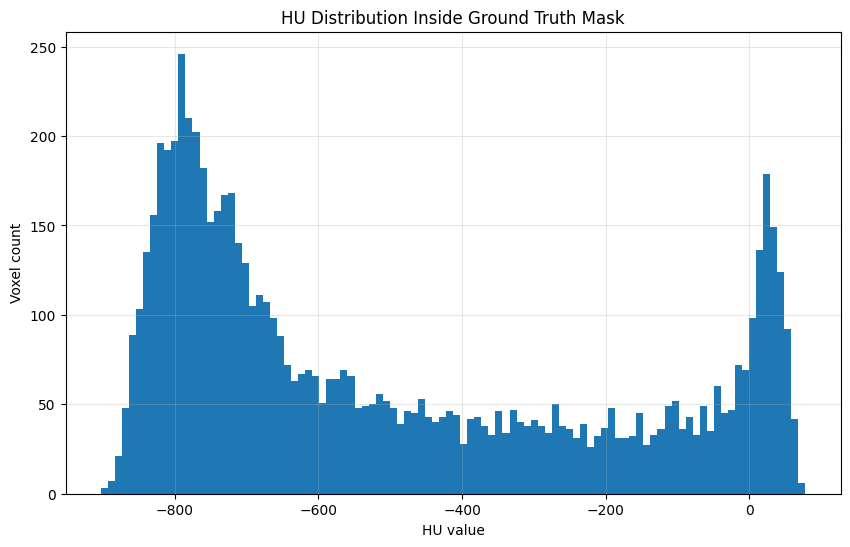

In [4]:
# ============================================================
# HU distribution inside GT mask
# ============================================================

# If GT mask is multi-channel, select one finding/channel
if gt_mask.ndim == 4:
    finding = 0
    gt_mask_single = gt_mask[finding]
else:
    gt_mask_single = gt_mask

# Convert GT to boolean mask
gt_bool = gt_mask_single > 0

# Extract HU values inside GT
gt_hu_values = ct[gt_bool]

# Remove NaN / inf if any
gt_hu_values = gt_hu_values[np.isfinite(gt_hu_values)]

print("Number of GT voxels:", gt_hu_values.size)

if gt_hu_values.size > 0:
    print("\nHU distribution inside GT mask")
    print("Min :", float(np.min(gt_hu_values)))
    print("P1  :", float(np.percentile(gt_hu_values, 1)))
    print("P5  :", float(np.percentile(gt_hu_values, 5)))
    print("P25 :", float(np.percentile(gt_hu_values, 25)))
    print("P50 :", float(np.percentile(gt_hu_values, 50)))  # median
    print("P75 :", float(np.percentile(gt_hu_values, 75)))
    print("P95 :", float(np.percentile(gt_hu_values, 95)))
    print("P99 :", float(np.percentile(gt_hu_values, 99)))
    print("Max :", float(np.max(gt_hu_values)))
    print("Mean:", float(np.mean(gt_hu_values)))
    print("Median:", float(np.median(gt_hu_values)))
    print("Std :", float(np.std(gt_hu_values)))

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(gt_hu_values, bins=100)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside Ground Truth Mask")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("GT mask is empty.")

Selected CTs: 543



Processed: 454
Missing CTs: 70
Missing masks: 19

Missing CT files:
  valid_1001_a_1.nii.gz
  valid_1055_a_1.nii.gz
  valid_1061_a_2.nii.gz
  valid_1077_a_2.nii.gz
  valid_1091_a_1.nii.gz
  valid_1102_a_2.nii.gz
  valid_1103_a_2.nii.gz
  valid_110_a_1.nii.gz
  valid_1113_a_2.nii.gz
  valid_1119_a_1.nii.gz
  valid_1141_a_2.nii.gz
  valid_114_b_2.nii.gz
  valid_1196_a_1.nii.gz
  valid_1213_a_1.nii.gz
  valid_1235_a_2.nii.gz
  valid_1261_a_2.nii.gz
  valid_147_a_2.nii.gz
  valid_189_a_1.nii.gz
  valid_1_a_2.nii.gz
  valid_280_a_2.nii.gz

Missing mask files:
  train_13000_a_2.nii.gz
  train_13011_a_2.nii.gz
  train_13014_a_2.nii.gz
  train_13025_a_2.nii.gz
  train_13043_a_1.nii.gz
  train_13097_b_2.nii.gz
  train_13125_a_2.nii.gz
  train_13218_b_2.nii.gz
  train_13278_c_1.nii.gz
  train_13365_a_2.nii.gz
  train_13380_a_1.nii.gz
  train_13423_a_2.nii.gz
  train_13459_a_2.nii.gz
  train_13484_a_2.nii.gz
  train_13490_a_1.nii.gz
  train_13521_a_1.nii.gz
  train_13593_b_2.nii.gz
  train_13604

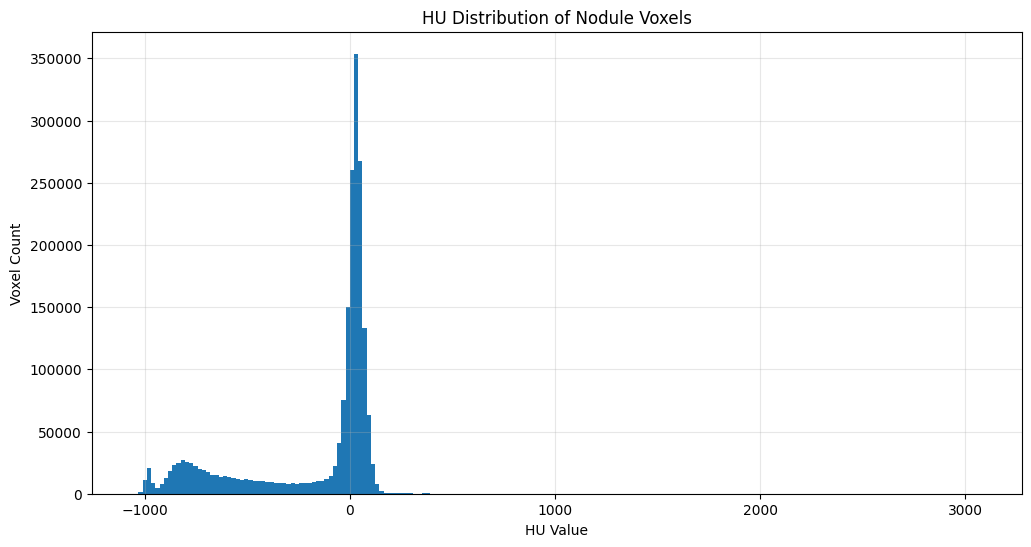

In [4]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# ============================================================
# Narrowest HU ranges containing given percentages of GT values
# ============================================================

def narrowest_hu_range(values, percentages=[1, 5, 10, 15, 50]):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    n = values.size

    if n == 0:
        print("No HU values found.")
        return {}

    results = {}

    for p in percentages:
        # Number of voxels needed to include p%
        window_size = max(1, int(np.ceil((p / 100) * n)))

        # Sliding window over sorted HU values
        starts = values[: n - window_size + 1]
        ends = values[window_size - 1 :]

        widths = ends - starts
        best_idx = int(np.argmin(widths))

        hu_min = float(starts[best_idx])
        hu_max = float(ends[best_idx])
        width = float(hu_max - hu_min)

        results[p] = {
            "min": hu_min,
            "max": hu_max,
            "width": width,
            "voxels": window_size,
        }

        print(f"{p}% HU range:")
        print(f"  Min HU : {hu_min:.2f}")
        print(f"  Max HU : {hu_max:.2f}")
        print(f"  Width  : {width:.2f}")
        print(f"  Voxels : {window_size}")
        print()

    return results


hu_ranges = narrowest_hu_range(gt_hu_values, percentages=[1, 5, 10, 25, 50])

1% HU range:
  Min HU : -832.00
  Max HU : -832.00
  Width  : 0.00
  Voxels : 5

5% HU range:
  Min HU : -823.00
  Max HU : -816.00
  Width  : 7.00
  Voxels : 22

10% HU range:
  Min HU : -832.00
  Max HU : -815.00
  Width  : 17.00
  Voxels : 44

25% HU range:
  Min HU : -841.00
  Max HU : -784.00
  Width  : 57.00
  Voxels : 109

50% HU range:
  Min HU : -845.00
  Max HU : -681.00
  Width  : 164.00
  Voxels : 218



In [6]:
hu_ranges_all = narrowest_hu_range(
    all_hu_values,
    percentages=[1, 5, 10, 25, 50]
)

1% HU range:
  Min HU : -1.00
  Max HU : 0.00
  Width  : 1.00
  Voxels : 20081

5% HU range:
  Min HU : 23.00
  Max HU : 28.00
  Width  : 5.00
  Voxels : 100401

10% HU range:
  Min HU : 21.00
  Max HU : 32.00
  Width  : 11.00
  Voxels : 200801

25% HU range:
  Min HU : 13.00
  Max HU : 43.00
  Width  : 30.00
  Voxels : 502002

50% HU range:
  Min HU : -12.00
  Max HU : 64.00
  Width  : 76.00
  Voxels : 1004004



In [ ]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Median:", float(np.median(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

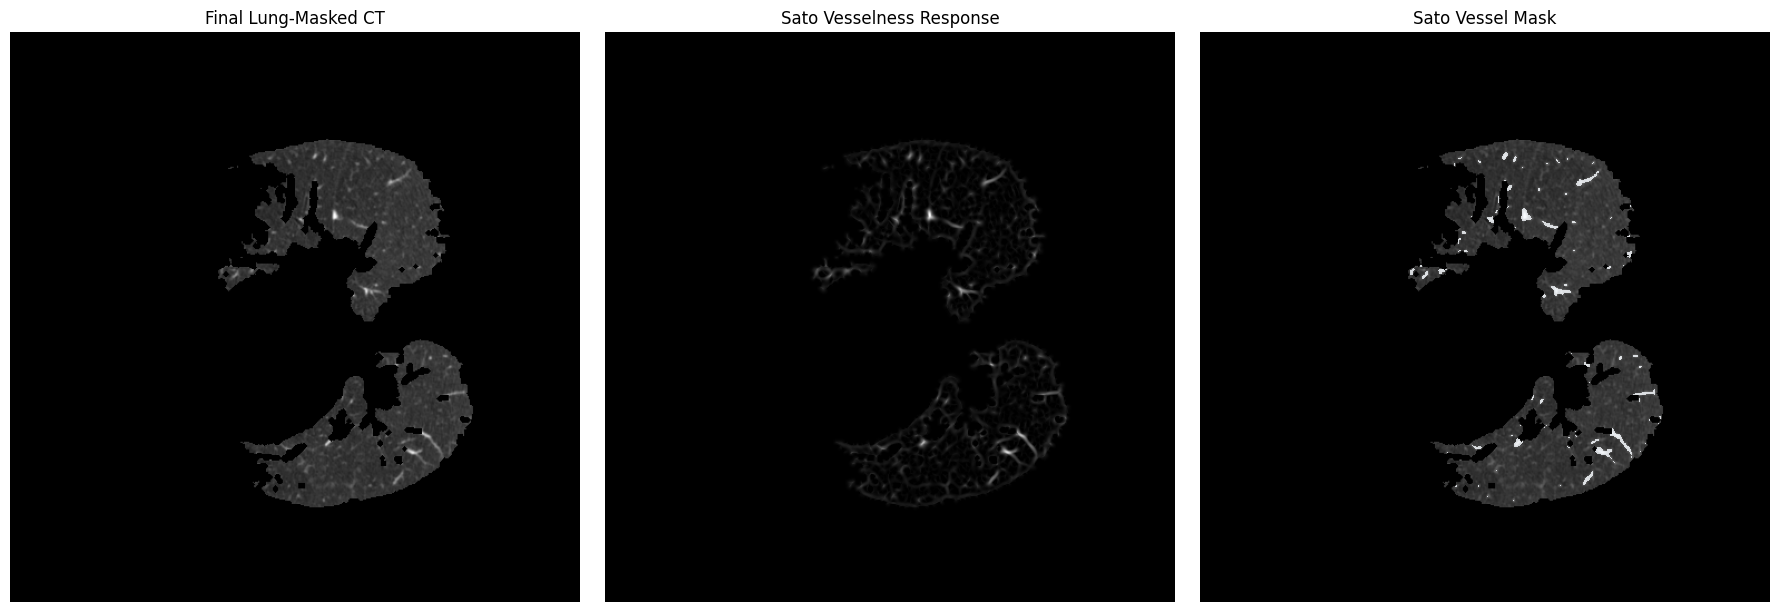

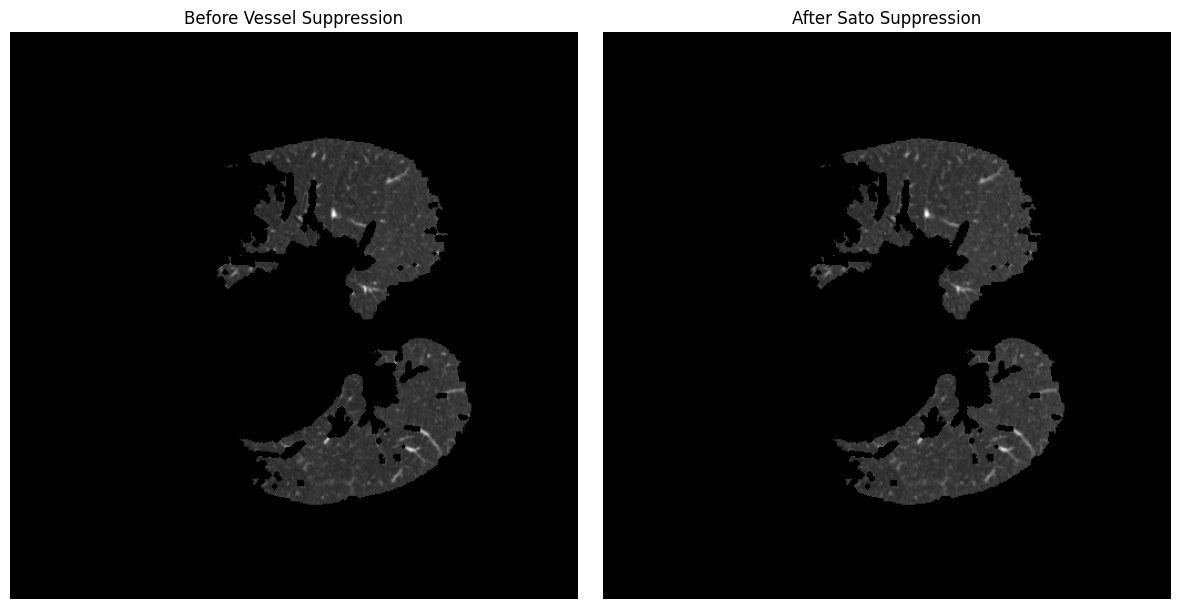

Slice index: 283

Sato vessel candidate pixel count on this slice:
Sato vessel pixels: 902


In [25]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.filters import sato


# ============================================================
# Helper: normalize one CT slice inside lung
# ============================================================
def normalize_lung_slice(ct_slice, lung_slice, hu_min=-900, hu_max=200):
    """
    Clip one CT slice and normalize to [0, 1].
    Outside lung is set to 0.
    """
    ct_clip = np.clip(ct_slice, hu_min, hu_max)
    ct_norm = (ct_clip - hu_min) / (hu_max - hu_min)
    ct_norm[~lung_slice] = 0
    return ct_norm


# ============================================================
# Helper: suppress vessels on one slice only
# ============================================================
def suppress_vessels_from_slice(
    ct_slice,
    vesselness_slice,
    lung_slice,
    percentile=3
):
    """
    Suppress likely vessel pixels on one 2D slice.
    Vessel pixels are replaced by local median values.
    """
    values = vesselness_slice[lung_slice]

    if values.size == 0:
        return ct_slice.copy(), np.zeros_like(lung_slice, dtype=bool)

    threshold = np.percentile(values, percentile)

    vessel_mask = (vesselness_slice >= threshold) & lung_slice

    local_median = ndimage.median_filter(ct_slice, size=3)

    ct_suppressed = ct_slice.copy()
    ct_suppressed[vessel_mask] = local_median[vessel_mask]

    return ct_suppressed, vessel_mask


# ============================================================
# 1. Extract selected slice
# ============================================================
ct_slice = ct_lung_only[:, :, slice_idx]
lung_slice = lungs_final[:, :, slice_idx]


# ============================================================
# 2. Normalize selected slice for vessel filter
# ============================================================
ct_norm_slice = normalize_lung_slice(
    ct_slice=ct_slice,
    lung_slice=lung_slice,
    hu_min=-900,
    hu_max=200
)


# ============================================================
# 3. Apply Sato vessel filter on 2D slice
# ============================================================
sato_slice = sato(
    ct_norm_slice,
    sigmas=(1, 2),
    black_ridges=False
)


# ============================================================
# 4. Suppress vessel pixels using Sato response
# ============================================================
sato_removed_slice, sato_mask_slice = suppress_vessels_from_slice(
    ct_slice=ct_slice,
    vesselness_slice=sato_slice,
    lung_slice=lung_slice,
    percentile=97
)


# ============================================================
# 5. Visualize CT, Sato response, and vessel mask
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Final Lung-Masked CT")
axes[0].axis("off")

axes[1].imshow(sato_slice, cmap="gray")
axes[1].set_title("Sato Vesselness Response")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray")
axes[2].imshow(
    np.ma.masked_where(~sato_mask_slice, sato_mask_slice),
    cmap="Blues",
    alpha=0.8,
    interpolation="none"
)
axes[2].set_title("Sato Vessel Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Visualize before/after vessel suppression
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Before Vessel Suppression")
axes[0].axis("off")

axes[1].imshow(sato_removed_slice, cmap="gray")
axes[1].set_title("After Sato Suppression")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Print statistics for this slice
# ============================================================
print("Slice index:", slice_idx)
print("\nSato vessel candidate pixel count on this slice:")
print("Sato vessel pixels:", int(sato_mask_slice.sum()))